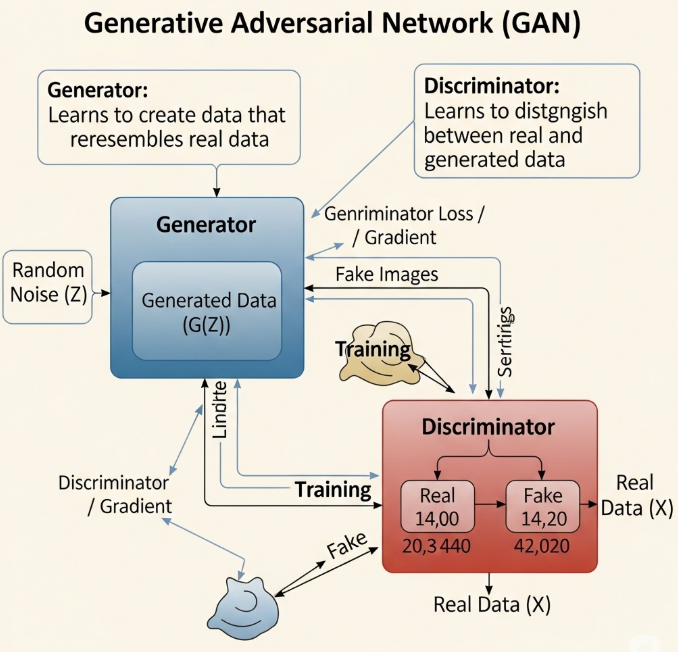

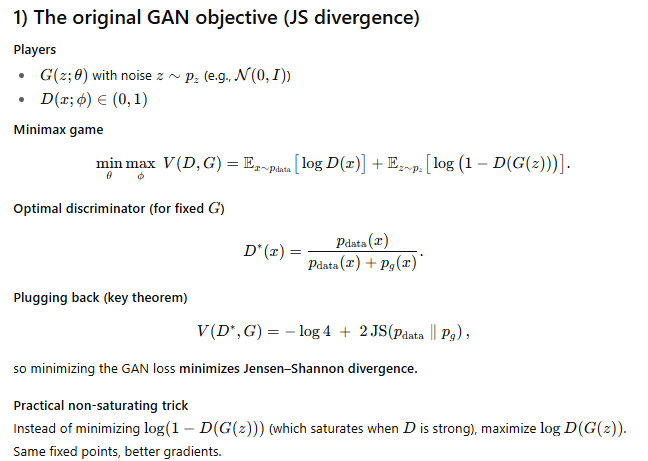

STEP 1 — Load a real image (MNIST):
We’ll treat an image as a probability distribution over pixel *locations*; brighter pixels carry more mass.

 - Selected example index: 42210, shape: (28, 28), pixel range: [0.000, 1.000]
 - Intuition: this single image is one draw from the *real data distribution* pdata(x).

STEP 2 — Create a 'fake' distribution far from the real one:
We shift the image to the right by many pixels with zero padding. This keeps total mass but moves it elsewhere, making supports almost disjoint.

STEP 3 — Measure divergence/distances for disjoint-ish supports:
 - Overlap mass (∑ min(p,q)) ≈ 0.1875 (0 means disjoint, 1 means identical).
 - JS(p||q) ≈ 0.5500 (max possible is ln2 ≈ 0.6931).
   THEORY: JS divergence is bounded; when supports barely overlap, the discriminator can perfectly separate real vs fake and the generator’s gradient *vanishes*.
 - Wasserstein-1 W1(p,q) ≈ 3.7196 pixel-moves.
   THEORY: W1 is the *minimal total travel* of mass to morph fake into real;

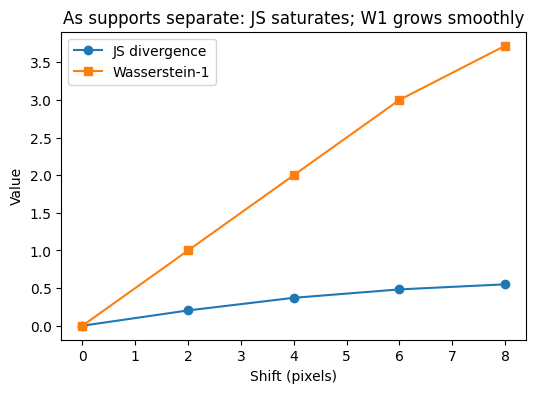


STEP 7 — Recap:
• Treating images as probability fields over pixel locations lets us compare distributions directly.
• When we made the fake far (disjoint support), JS → ln2 (saturates) → GAN generator gradients vanish.
• Wasserstein-1 stayed informative, quantifying *how far* mass must move → WGAN gives usable gradients.
• Bringing supports together reduces both JS and W1; at alignment, both approach zero.

STEP 8 — Visualize the real vs fake images:


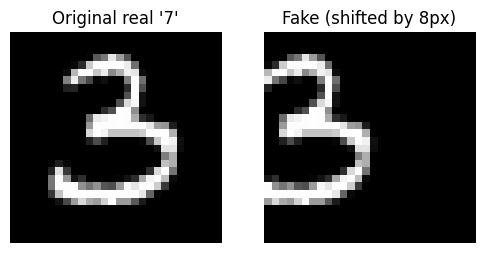

Left: the true MNIST digit (real sample from pdata).
Right: our deliberately shifted version (fake sample from pg).
Notice how they hardly overlap — this corresponds to *disjoint supports* in distributional terms.
This is why JS divergence saturated and W1 distance stayed meaningful.


In [ ]:
# --- Colab-ready demo: JS vs Wasserstein on a real image ----------------------
# It narrates the theory via print statements as it goes.

import numpy as np
import matplotlib.pyplot as plt

# 1) Data: MNIST (built-in in tf.keras)
print("STEP 1 — Load a real image (MNIST):")
print("We’ll treat an image as a probability distribution over pixel *locations*;"
      " brighter pixels carry more mass.\n")
try:
    import tensorflow as tf
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow", "-q"])
    import tensorflow as tf

# Load MNIST and pick a random '7' (or any digit if 7 unavailable)
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
idxs = np.where(y_train == 3)[0]
if len(idxs) == 0:
    idxs = np.arange(len(x_train))
i = np.random.choice(idxs)
img28 = x_train[i].astype(np.float32) / 255.0  # shape (28,28)

print(f" - Selected example index: {i}, shape: {img28.shape}, pixel range: [{img28.min():.3f}, {img28.max():.3f}]")
print(" - Intuition: this single image is one draw from the *real data distribution* pdata(x).")




# Utility: downsample to 14x14 (for fast optimal transport)
def downsample_2x(img):
    h, w = img.shape
    img = img[:h - (h % 2), :w - (w % 2)]
    H, W = img.shape[0] // 2, img.shape[1] // 2
    return img.reshape(H, 2, W, 2).mean(axis=(1, 3))

# Utility: shift with zero padding (no wraparound)
def shift_image_zero(img, dx=0, dy=0):
    H, W = img.shape
    out = np.zeros_like(img)
    x0 = max(0, dx); x1 = min(W, W + dx)
    y0 = max(0, dy); y1 = min(H, H + dy)
    xs0 = max(0, -dx); xs1 = xs0 + (x1 - x0)
    ys0 = max(0, -dy); ys1 = ys0 + (y1 - y0)
    out[ys0:ys1, xs0:xs1] = img[y0:y1, x0:x1]
    return out

# Probability normalization on a grid
def normalize_to_prob(img, eps=1e-12):
    arr = np.clip(img, 0.0, None)
    s = arr.sum()
    if s < eps:
        # fallback: if image is (almost) empty, spread uniform mass
        arr = np.ones_like(arr)
        s = arr.sum()
    return arr / s

# Jensen–Shannon divergence between two discrete distributions on the same support
def js_divergence(p, q, eps=1e-12):
    p = np.clip(p, eps, 1.0)
    q = np.clip(q, eps, 1.0)
    m = 0.5 * (p + q)
    def kl(a, b):
        return np.sum(a * (np.log(a) - np.log(b)))
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)

# Wasserstein-1 (Earth-Mover) distance on the 2D pixel grid using POT (Optimal Transport)
def w1_emd_2d(p, q):
    try:
        import ot  # POT: Python Optimal Transport
    except Exception:
        import sys, subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "pot", "-q"])
        import ot
    H, W = p.shape
    a = p.reshape(-1).astype(np.float64)
    b = q.reshape(-1).astype(np.float64)

    # Ground cost = Euclidean distance between pixel coordinates
    ys, xs = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
    coords = np.stack([ys.reshape(-1), xs.reshape(-1)], axis=1).astype(np.float64)
    # Pairwise distances
    diff = coords[:, None, :] - coords[None, :, :]
    M = np.sqrt((diff ** 2).sum(-1))  # shape (N, N), N = H*W

    # EMD cost equals W1 for this discrete setup
    w1 = ot.emd2(a, b, M)
    return float(w1)

# 2) Build a clearly "fake" image by shifting the real one a lot (disjoint supports)
print("\nSTEP 2 — Create a 'fake' distribution far from the real one:")
print("We shift the image to the right by many pixels with zero padding."
      " This keeps total mass but moves it elsewhere, making supports almost disjoint.")
SHIFT_X, SHIFT_Y = 8, 0  # big move on 28x28
fake28_far = shift_image_zero(img28, dx=SHIFT_X, dy=SHIFT_Y)

# Optional binarization to concentrate support (more 'disjointness')
thr = 0.5
real28_bin = (img28 > thr).astype(np.float32)
fake28_bin = (fake28_far > thr).astype(np.float32)
if real28_bin.sum() < 10:  # be robust if threshold is too high
    real28_bin = (img28 > 0.25).astype(np.float32)
    fake28_bin = (fake28_far > 0.25).astype(np.float32)

# Downsample after shifting for faster OT
real14 = downsample_2x(real28_bin)
fake14 = downsample_2x(fake28_bin)

# Normalize to probability distributions over pixel locations
p_real = normalize_to_prob(real14)
p_fake = normalize_to_prob(fake14)

# 3) Initial metrics: JS vs W1
print("\nSTEP 3 — Measure divergence/distances for disjoint-ish supports:")
JS0 = js_divergence(p_real, p_fake)
W10 = w1_emd_2d(p_real, p_fake)
ln2 = np.log(2.0)
overlap0 = np.minimum(p_real, p_fake).sum()

print(f" - Overlap mass (∑ min(p,q)) ≈ {overlap0:.4f} (0 means disjoint, 1 means identical).")
print(f" - JS(p||q) ≈ {JS0:.4f} (max possible is ln2 ≈ {ln2:.4f}).")
print("   THEORY: JS divergence is bounded; when supports barely overlap,"
      " the discriminator can perfectly separate real vs fake and the generator’s gradient *vanishes*.")
print(f" - Wasserstein-1 W1(p,q) ≈ {W10:.4f} pixel-moves.")
print("   THEORY: W1 is the *minimal total travel* of mass to morph fake into real;"
      " it stays informative even if supports don’t overlap.\n")

# 4) Bring the fake closer step-by-step by reducing the shift
print("STEP 4 — Move the fake mass toward the real mass and watch the numbers:")
print("We reduce the spatial shift in steps; supports overlap more and more.\n")

shifts = [8, 6, 4, 2, 0]
results = []
for s in shifts:
    f28 = shift_image_zero(img28, dx=s, dy=0)
    fbin = (f28 > thr).astype(np.float32)
    if fbin.sum() < 10:
        fbin = (f28 > 0.25).astype(np.float32)
    f14 = downsample_2x(fbin)
    p_f = normalize_to_prob(f14)

    JS = js_divergence(p_real, p_f)
    W1 = w1_emd_2d(p_real, p_f)
    overlap = np.minimum(p_real, p_f).sum()
    results.append((s, JS, W1, overlap))

    print(f" Shift = {s:2d} px | overlap ≈ {overlap:.4f} | JS ≈ {JS:.4f} "
          f"({JS/ln2*100:.1f}% of ln2) | W1 ≈ {W1:.4f}")
    if JS > 0.6 * ln2:
        print("   → JS near its ceiling: discriminator would be almost perfect; generator gets tiny/unstable gradients.")
    elif JS < 0.15:
        print("   → JS small: supports overlap strongly; discriminator is uncertain; generator gradients are non-vanishing.")
    if s > 0:
        print("   → W1 still positive: tells *how far* to move mass; gradient direction is meaningful.")
    else:
        print("   → W1 near zero: fake and real are aligned; optimal transport cost is tiny.\n")

# 5) Optional: a smooth morph by convex blending (not transport, but shows monotonic trends)
print("\nSTEP 5 — (Optional) Blend fake→real by convex mixing to see monotone trends in metrics.")
print("Note: blending changes mass rather than moving it; W1 reduces, JS reduces, but it’s not physical transport.")
ts = np.linspace(0, 1, 6)
blend_JS, blend_W1 = [], []
for t in ts:
    blend = normalize_to_prob((1-t) * fake14 + t * p_real)  # blend distributions directly
    JSb = js_divergence(p_real, blend)
    W1b = w1_emd_2d(p_real, blend)
    blend_JS.append(JSb); blend_W1.append(W1b)
    print(f"  t = {t:.2f} | JS ≈ {JSb:.4f} | W1 ≈ {W1b:.4f}")

# 6) Tiny plot to visualize the two metrics across shift steps
print("\nSTEP 6 — Visual summary plot (no specific colors set):")
fig, ax = plt.subplots(figsize=(6,4))
ax.plot([s for s,_,_,_ in results], [JS for _,JS,_,_ in results], marker="o", label="JS divergence")
ax.plot([s for s,_,_,_ in results], [W1 for _,_,W1,_ in results], marker="s", label="Wasserstein-1")
ax.set_xlabel("Shift (pixels)"); ax.set_ylabel("Value")
ax.set_title("As supports separate: JS saturates; W1 grows smoothly")
ax.legend()
plt.show()

# 7) Final recap
print("\nSTEP 7 — Recap:")
print("• Treating images as probability fields over pixel locations lets us compare distributions directly.")
print("• When we made the fake far (disjoint support), JS → ln2 (saturates) → GAN generator gradients vanish.")
print("• Wasserstein-1 stayed informative, quantifying *how far* mass must move → WGAN gives usable gradients.")
print("• Bringing supports together reduces both JS and W1; at alignment, both approach zero.")


# 8) Show original and final fake images side by side
print("\nSTEP 8 — Visualize the real vs fake images:")

fig, axs = plt.subplots(1, 2, figsize=(6,3))
axs[0].imshow(img28, cmap="gray")
axs[0].set_title("Original real '7'")
axs[0].axis("off")

axs[1].imshow(fake28_far, cmap="gray")
axs[1].set_title(f"Fake (shifted by {SHIFT_X}px)")
axs[1].axis("off")

plt.show()

print("Left: the true MNIST digit (real sample from pdata).")
print("Right: our deliberately shifted version (fake sample from pg).")
print("Notice how they hardly overlap — this corresponds to *disjoint supports* in distributional terms.")
print("This is why JS divergence saturated and W1 distance stayed meaningful.")


In [ ]:
import numpy as np

def js_divergence(p, q, eps=1e-12):
    m = 0.5*(p+q)
    def kl(a,b):
        a = np.clip(a, eps, 1.0); b = np.clip(b, eps, 1.0)
        return np.sum(a * (np.log(a) - np.log(b)))
    return 0.5*kl(p,m) + 0.5*kl(q,m)

xs = np.linspace(-8, 8, 4000)
def pdf(mu, sigma=1.0):
    return np.exp(-(xs-mu)**2/(2*sigma**2)) / (np.sqrt(2*np.pi)*sigma)

p = pdf(0,1); p /= p.sum()
for delta in [0.0, 0.5, 1.0, 2.0, 4.0]:
    q = pdf(delta,1); q /= q.sum()
    print(delta, js_divergence(p,q))


0.0 0.0
0.5 0.030311300456494973
1.0 0.11142148174391828
2.0 0.33683081803216974
4.0 0.6327192378889092


In [ ]:
def gradient_penalty(critic, real, fake):
    import torch
    bsz = real.size(0)
    eps = torch.rand(bsz, 1, 1, 1, device=real.device)
    hat = eps*real + (1-eps)*fake.detach()
    hat.requires_grad_(True)
    out = critic(hat)
    grad = torch.autograd.grad(out.sum(), hat, create_graph=True)[0]
    gp = ((grad.view(bsz, -1).norm(2, dim=1) - 1.0)**2).mean()
    return gp


STEP 1 — Load a real COLOR image (CIFAR-10):
CIFAR-10 images are RGB, shape (32, 32, 3). We'll pick a random example.
THEORY: We'll treat an image as a probability distribution over pixel *locations*; brighter pixels carry more mass. For color, we marginalize RGB into brightness mass, so the distribution lives on the 2D grid (i,j).

 - Selected example idx: 21000, label: airplane, shape: (32, 32, 3), pixel range: [0.145, 0.902]
 - Intuition: this single image is one draw from the *real data distribution* p_data(x).

STEP 2 — Create a 'fake' image far from the real one:
We spatially SHIFT the image with zero padding. This moves its mass apart, making supports overlap less.
 - Applied shift: dx=10, dy=0
 - THEORY: When real and fake put mass in different places (little overlap), a JS-based GAN gives vanishing gradients to the generator, while W1 remains informative.

STEP 3 — Convert color images to probability distributions over pixel LOCATIONS:
We marginalize color -> brightness mass b

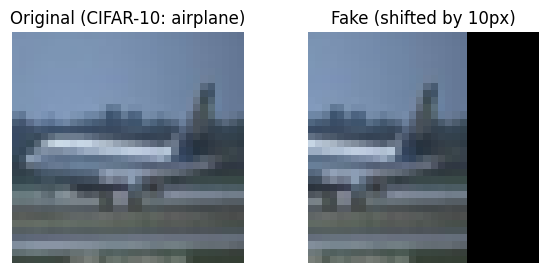

Left: the true CIFAR-10 image (a real sample from p_data).
Right: our deliberately shifted version (a fake sample from p_g).
They hardly overlap spatially — this corresponds to *disjoint supports* and explains why JS saturated while W1 remained large.

STEP 7 — Visualize intermediate shifts (watch fake align with real):


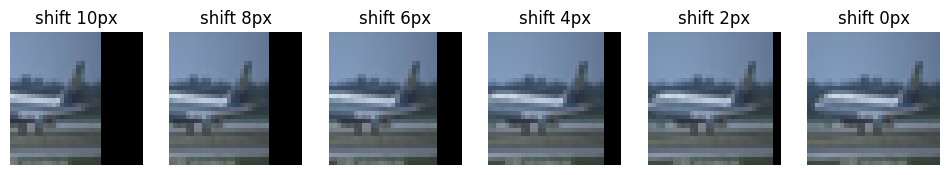

As shift decreases, the fake mass moves back toward the real image's locations. This increases support overlap, reduces JS (less separability), and reduces W1 (less transport needed).

STEP 8 — Plot JS divergence and W1 distance versus shift amount:


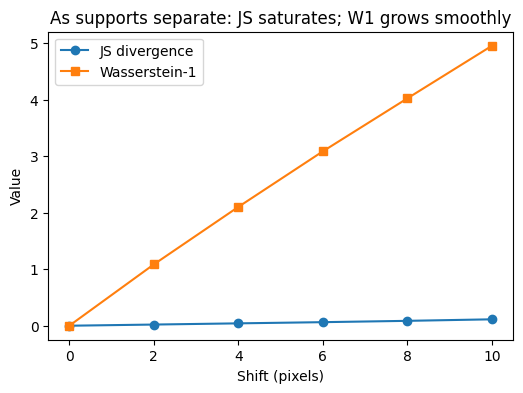

STEP 9 — Note on COLOR handling:
We purposely marginalized RGB to brightness mass over (i,j) so we could use 2D optimal transport cleanly.
Alternative advanced option: define a 3D ground metric over (i,j,channel) and transport in that space, or compute JS per-channel and average. The qualitative takeaway remains: JS can saturate on disjoint supports, while W1 provides smoother, informative gradients.

STEP 10 — Recap (GAN theory connection):
• In the original GAN, the generator minimizes (a surrogate of) JS divergence via the discriminator.
• When real and fake supports barely overlap, JS approaches its bound (≈ ln2), discriminator becomes nearly perfect,
  and generator gradients vanish → instability and mode collapse risk.
• In WGAN, the objective approximates W1 distance, which changes smoothly with *how far* mass must move,
  providing useful gradients even when supports are disjoint.
• Practically: WGAN + Lipschitz-enforced critic (e.g., gradient penalty or spectral norm) stabiliz

In [ ]:
# ==================== Colab-ready Demo: JS vs W1 on a COLOR image (CIFAR-10) ====================
# This script narrates theory via print statements at each step.
# We view an image as a probability distribution over pixel locations (mass ∝ brightness),
# and compare "real" (original) vs "fake" (shifted) with JS divergence and Wasserstein-1 distance.

import numpy as np
import matplotlib.pyplot as plt

#----------------------------------------------------------------------------------
# STEP 1 — Load a real color image (CIFAR-10) and explain the setup
#----------------------------------------------------------------------------------
print("STEP 1 — Load a real COLOR image (CIFAR-10):")
print("CIFAR-10 images are RGB, shape (32, 32, 3). We'll pick a random example.\n"
      "THEORY: We'll treat an image as a probability distribution over pixel *locations*;"
      " brighter pixels carry more mass. For color, we marginalize RGB into brightness mass,"
      " so the distribution lives on the 2D grid (i,j).\n")

# Install tensorflow only if needed
try:
    import tensorflow as tf
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow", "-q"])
    import tensorflow as tf

# Load CIFAR-10
(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()
y_train = y_train.reshape(-1)
class_names = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

# Choose a random example
i = np.random.randint(0, len(x_train))
i = 21000
img32 = x_train[i].astype(np.float32) / 255.0  # (32,32,3) in [0,1]
label = class_names[y_train[i]]

print(f" - Selected example idx: {i}, label: {label}, shape: {img32.shape},"
      f" pixel range: [{img32.min():.3f}, {img32.max():.3f}]")
print(" - Intuition: this single image is one draw from the *real data distribution* p_data(x).")

#----------------------------------------------------------------------------------
# Utilities
#----------------------------------------------------------------------------------
def rgb_to_mass(img, eps=1e-12):
    """
    Convert RGB image (H,W,3) to a nonnegative 'mass' image (H,W) by summing channels.
    (You could also use luminance weights; summation is simple and monotone.)
    """
    mass = np.clip(img, 0.0, None).sum(axis=-1)  # sum R+G+B
    # If the image is (almost) zero, fall back to uniform
    if mass.sum() < eps:
        mass = np.ones_like(mass)
    return mass

def normalize_to_prob(arr2d, eps=1e-12):
    arr = np.clip(arr2d, 0.0, None)
    s = arr.sum()
    if s < eps:
        arr = np.ones_like(arr)
        s = arr.sum()
    return arr / s

def shift_image_zero_rgb(img, dx=0, dy=0):
    """
    Spatial shift with zero padding (no wrap).
    img: (H,W,3). Returns shifted image of same shape.
    """
    H, W, C = img.shape
    out = np.zeros_like(img)
    x0 = max(0, dx); x1 = min(W, W + dx)
    y0 = max(0, dy); y1 = min(H, H + dy)
    xs0 = max(0, -dx); xs1 = xs0 + (x1 - x0)
    ys0 = max(0, -dy); ys1 = ys0 + (y1 - y0)
    out[ys0:ys1, xs0:xs1, :] = img[y0:y1, x0:x1, :]
    return out

def js_divergence(p, q, eps=1e-12):
    """
    JS divergence between two discrete distributions on same support.
    """
    p = np.clip(p, eps, 1.0)
    q = np.clip(q, eps, 1.0)
    m = 0.5 * (p + q)
    def kl(a, b):
        return np.sum(a * (np.log(a) - np.log(b)))
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)

def w1_emd_2d(p, q):
    """
    Wasserstein-1 (Earth-Mover) distance on pixel grid via Optimal Transport (POT library).
    Cost = Euclidean distance between pixel coordinates.
    """
    try:
        import ot  # POT: Python Optimal Transport
    except Exception:
        import sys, subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "pot", "-q"])
        import ot

    H, W = p.shape
    a = p.reshape(-1).astype(np.float64)
    b = q.reshape(-1).astype(np.float64)

    ys, xs = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
    coords = np.stack([ys.reshape(-1), xs.reshape(-1)], axis=1).astype(np.float64)

    diff = coords[:, None, :] - coords[None, :, :]
    M = np.sqrt((diff ** 2).sum(-1))  # ground distance between pixel locations

    w1 = ot.emd2(a, b, M)            # EMD cost equals W1 for discrete setup
    return float(w1)

#----------------------------------------------------------------------------------
# STEP 2 — Create a clearly “fake” version by shifting (disjoint-ish supports)
#----------------------------------------------------------------------------------
print("\nSTEP 2 — Create a 'fake' image far from the real one:")
print("We spatially SHIFT the image with zero padding. This moves its mass apart, making supports overlap less.")
SHIFT_X, SHIFT_Y = 10, 0  # choose a big horizontal move on 32×32
fake32_far = shift_image_zero_rgb(img32, dx=SHIFT_X, dy=SHIFT_Y)

print(f" - Applied shift: dx={SHIFT_X}, dy={SHIFT_Y}")
print(" - THEORY: When real and fake put mass in different places (little overlap),"
      " a JS-based GAN gives vanishing gradients to the generator, while W1 remains informative.")

#----------------------------------------------------------------------------------
# STEP 3 — Turn both into probability distributions over pixel locations
#----------------------------------------------------------------------------------
print("\nSTEP 3 — Convert color images to probability distributions over pixel LOCATIONS:")
print("We marginalize color -> brightness mass by summing RGB per pixel, then normalize to sum to 1.")
mass_real = rgb_to_mass(img32)   # (32,32)
mass_fake = rgb_to_mass(fake32_far)

p_real = normalize_to_prob(mass_real)
p_fake = normalize_to_prob(mass_fake)

print(f" - p_real sum: {p_real.sum():.6f} (should be 1.0), p_fake sum: {p_fake.sum():.6f} (should be 1.0)")
print(" - This interpretation lets us compare distributions on the 2D grid with JS and W1.\n")

#----------------------------------------------------------------------------------
# STEP 4 — Measure JS and W1 with disjoint-ish supports
#----------------------------------------------------------------------------------
print("STEP 4 — Measure divergence/distances for the far-shifted fake:")
ln2 = np.log(2.0)
overlap0 = np.minimum(p_real, p_fake).sum()
JS0 = js_divergence(p_real, p_fake)
W10 = w1_emd_2d(p_real, p_fake)

print(f" - Overlap mass (∑ min(p,q)) ≈ {overlap0:.4f} (0=disjoint, 1=identical).")
print(f" - JS(p||q) ≈ {JS0:.4f} (bounded above by ln2 ≈ {ln2:.4f}).")
print("   THEORY: With little overlap, the discriminator is nearly perfect; JS saturates and generator gradients vanish.")
print(f" - Wasserstein-1 W1(p,q) ≈ {W10:.4f} pixel-moves.")
print("   THEORY: W1 measures minimal total transport to morph fake into real; stays meaningful even if supports don't overlap.\n")

#----------------------------------------------------------------------------------
# STEP 5 — Move fake toward real (progressively smaller shifts), track metrics
#----------------------------------------------------------------------------------
print("STEP 5 — Move fake mass toward real mass and watch JS vs W1 evolve:")
print("We reduce the shift in steps; supports overlap more and more.\n")

shifts = [10, 8, 6, 4, 2, 0]
results = []
for s in shifts:
    f32 = shift_image_zero_rgb(img32, dx=s, dy=0)
    p_f = normalize_to_prob(rgb_to_mass(f32))
    JS = js_divergence(p_real, p_f)
    W1 = w1_emd_2d(p_real, p_f)
    overlap = np.minimum(p_real, p_f).sum()
    results.append((s, JS, W1, overlap))

    print(f" Shift = {s:2d}px | overlap ≈ {overlap:.4f} | JS ≈ {JS:.4f} "
          f"({JS/ln2*100:.1f}% of ln2) | W1 ≈ {W1:.4f}")
    if JS > 0.6 * ln2:
        print("   → JS near its ceiling: discriminator would be almost perfect; generator gets tiny/unstable gradients.")
    elif JS < 0.15:
        print("   → JS small: strong overlap; discriminator is uncertain; generator gradients are non-vanishing.")
    if s > 0:
        print("   → W1 still positive: indicates *how far* to move mass; provides a sensible direction.")
    else:
        print("   → W1 near zero: fake and real are aligned; optimal transport cost is tiny.\n")

#----------------------------------------------------------------------------------
# STEP 6 — Visualize ORIGINAL vs FAR-SHIFTED FAKE (color)
#----------------------------------------------------------------------------------
print("STEP 6 — Visualize the REAL vs FAR-SHIFTED FAKE images:")
fig, axs = plt.subplots(1, 2, figsize=(7,3))
axs[0].imshow(img32)
axs[0].set_title(f"Original (CIFAR-10: {label})")
axs[0].axis("off")

axs[1].imshow(fake32_far)
axs[1].set_title(f"Fake (shifted by {SHIFT_X}px)")
axs[1].axis("off")

plt.show()

print("Left: the true CIFAR-10 image (a real sample from p_data).")
print("Right: our deliberately shifted version (a fake sample from p_g).")
print("They hardly overlap spatially — this corresponds to *disjoint supports* and explains why JS saturated while W1 remained large.\n")

#----------------------------------------------------------------------------------
# STEP 7 — Visualize INTERMEDIATE SHIFTS in a small grid
#----------------------------------------------------------------------------------
print("STEP 7 — Visualize intermediate shifts (watch fake align with real):")
cols = len(shifts)
fig, axs = plt.subplots(1, cols, figsize=(2*cols, 2))
for k, s in enumerate(shifts):
    ax = axs[k]
    img_s = shift_image_zero_rgb(img32, dx=s, dy=0)
    ax.imshow(img_s)
    ax.set_title(f"shift {s}px")
    ax.axis("off")
plt.show()

print("As shift decreases, the fake mass moves back toward the real image's locations."
      " This increases support overlap, reduces JS (less separability), and reduces W1 (less transport needed).\n")

#----------------------------------------------------------------------------------
# STEP 8 — Plot JS vs W1 across shifts
#----------------------------------------------------------------------------------
print("STEP 8 — Plot JS divergence and W1 distance versus shift amount:")
fig, ax = plt.subplots(figsize=(6,4))
ax.plot([s for s,_,_,_ in results], [JS for _,JS,_,_ in results], marker="o", label="JS divergence")
ax.plot([s for s,_,_,_ in results], [W1 for _,_,W1,_ in results], marker="s", label="Wasserstein-1")
ax.set_xlabel("Shift (pixels)")
ax.set_ylabel("Value")
ax.set_title("As supports separate: JS saturates; W1 grows smoothly")
ax.legend()
plt.show()

#----------------------------------------------------------------------------------
# STEP 9 — (Optional) Conceptual note about color handling
#----------------------------------------------------------------------------------
print("STEP 9 — Note on COLOR handling:")
print("We purposely marginalized RGB to brightness mass over (i,j) so we could use 2D optimal transport cleanly.")
print("Alternative advanced option: define a 3D ground metric over (i,j,channel) and transport in that space,"
      " or compute JS per-channel and average. The qualitative takeaway remains: JS can saturate on disjoint supports,"
      " while W1 provides smoother, informative gradients.\n")

#----------------------------------------------------------------------------------
# STEP 10 — Recap: why this matters for GANs
#----------------------------------------------------------------------------------
print("STEP 10 — Recap (GAN theory connection):")
print("• In the original GAN, the generator minimizes (a surrogate of) JS divergence via the discriminator.\n"
      "• When real and fake supports barely overlap, JS approaches its bound (≈ ln2), discriminator becomes nearly perfect,\n"
      "  and generator gradients vanish → instability and mode collapse risk.\n"
      "• In WGAN, the objective approximates W1 distance, which changes smoothly with *how far* mass must move,\n"
      "  providing useful gradients even when supports are disjoint.\n"
      "• Practically: WGAN + Lipschitz-enforced critic (e.g., gradient penalty or spectral norm) stabilizes training.")


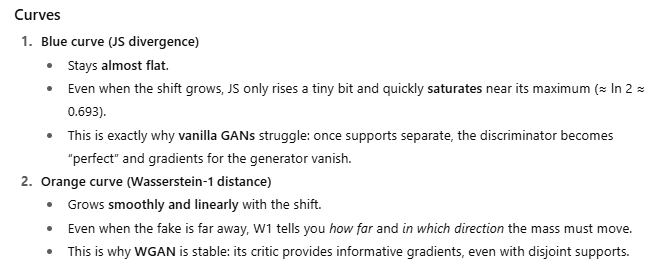

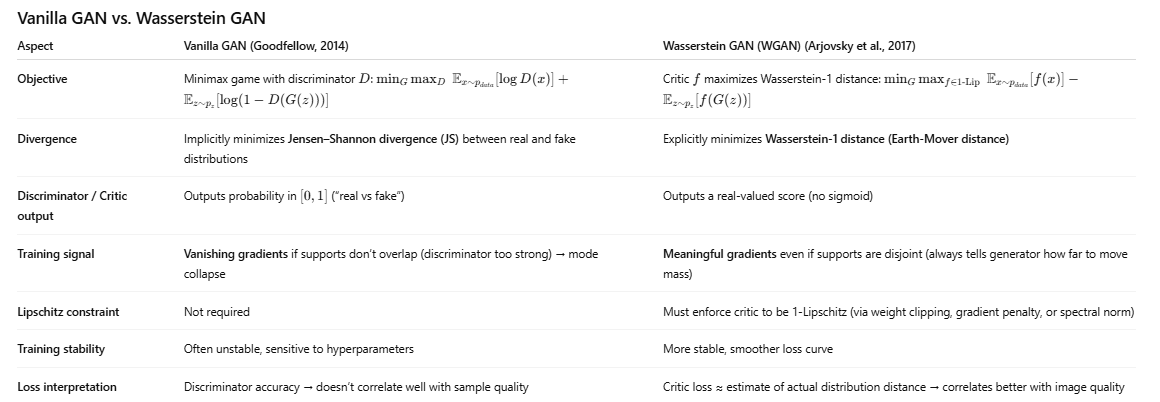

In [ ]:
# ========================== Narrated WGAN-GP on 2D Two-Moons (Fixed) ==========================
# This script prints the theory behind each step AND trains a tiny WGAN-GP to make it concrete.
# Fix applied: gradient penalty for logging is computed OUTSIDE any torch.no_grad() block.

import os, sys, subprocess, numpy as np, matplotlib.pyplot as plt, math, time, random

print("INTRO — What you'll see:")
print("• A critic (no sigmoid) estimates Wasserstein-1 distance; a generator transports noise mass to match real data.")
print("• We enforce 1-Lipschitz on the critic using a GRADIENT PENALTY (WGAN-GP).")
print("• You'll see prints that connect each training step to the theory.\n")

# --- deps ---
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "-q"])
    import torch
    import torch.nn as nn
    import torch.optim as optim

try:
    from sklearn.datasets import make_moons
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn", "-q"])
    from sklearn.datasets import make_moons

# --- seeds for reproducibility ---
seed = 42
np.random.seed(seed); random.seed(seed); torch.manual_seed(seed)

# ===================== STEP 1 — Data as a distribution =====================
print("STEP 1 — Data as a distribution:")
print("We use 'two moons' in R^2. Think of it as p_data(x). The generator will learn to transport noise mass to this shape.\n")
X, _ = make_moons(n_samples=20000, noise=0.05)
X = (X - X.mean(0)) / X.std(0)
real = torch.tensor(X, dtype=torch.float32)

# ===================== STEP 2 — Models (no sigmoid in critic) =====================
print("STEP 2 — Critic vs Generator, and why critic has NO sigmoid:")
print("In WGAN, the critic outputs a real score, not a probability; this matches the Kantorovich–Rubinstein dual for W1.\n")

class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 256), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 256), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1)
        )
    def forward(self, x): return self.net(x)

class Generator(nn.Module):
    def __init__(self, zdim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(zdim, 128), nn.ReLU(inplace=True),
            nn.Linear(128, 128), nn.ReLU(inplace=True),
            nn.Linear(128, 2)
        )
        self.zdim = zdim
    def forward(self, z): return self.net(z)
    def sample(self, n): return self.forward(torch.randn(n, self.zdim, device=self.net[0].weight.device))

C, G = Critic(), Generator()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
C, G, real = C.to(device), G.to(device), real.to(device)

# ===================== STEP 3 — Lipschitz via Gradient Penalty =====================
print("STEP 3 — Enforcing 1-Lipschitz on the critic (why it matters):")
print("W1 dual requires the critic to be 1-Lipschitz; gradient penalty keeps ||∇_x f(x)|| ≈ 1 along data–model lines.\n")

def grad_penalty(critic, xr, xf):
    # xr, xf: (B,2) real and fake samples
    eps = torch.rand(xr.size(0), 1, device=device)
    xhat = eps * xr + (1 - eps) * xf
    xhat.requires_grad_(True)
    out = critic(xhat).sum()
    grad, = torch.autograd.grad(out, xhat, create_graph=True)
    gp = ((grad.norm(2, dim=1) - 1) ** 2).mean()
    return gp

# ===================== STEP 4 — Training setup (TTUR) =====================
print("STEP 4 — Two-time-scale updates (TTUR) and losses:")
print("We update the critic multiple steps per generator step to keep its estimate of W1 useful.\n")

bs = 512
critic_steps = 5
steps = 2000   # total generator steps
lrC, lrG = 1e-4, 1e-4
LAMBDA_GP = 10.0

optC = optim.Adam(C.parameters(), lr=lrC, betas=(0.5, 0.9))
optG = optim.Adam(G.parameters(), lr=lrG, betas=(0.5, 0.9))

def plot_samples(step_idx, G, real):
    with torch.no_grad():
        fake = G.sample(5000).cpu().numpy()
    r = real[:5000].detach().cpu().numpy()
    plt.figure(figsize=(4,4))
    plt.scatter(r[:,0], r[:,1], s=4, alpha=0.35, label="real")
    plt.scatter(fake[:,0], fake[:,1], s=4, alpha=0.35, label="fake")
    plt.legend(); plt.title(f"Step {step_idx}: real vs fake")
    os.makedirs("wgan_gp_frames", exist_ok=True)
    plt.savefig(f"wgan_gp_frames/step_{step_idx:05d}.png", dpi=120)
    plt.close()

print("TRAIN — You’ll see:")
print("• Critic loss ≈ −W1 + λ·GP (we ASCEND critic, DESCEND generator).")
print("• GP term near 0 means near-1 gradients → good Lipschitz behavior.")
print("• As training proceeds, fake mass should curl into the 'moons'.\n")

# ===================== TRAIN LOOP =====================
for step in range(1, steps + 1):
    # ---- Critic updates
    for _ in range(critic_steps):
        idx = torch.randint(0, len(real), (bs,), device=device)
        xr = real[idx]
        xf = G.sample(bs).detach()  # detach: critic update shouldn't backprop through G

        optC.zero_grad()
        # maximize E[f(x_real)] - E[f(x_fake)]  <=> minimize its negative
        lossC = -(C(xr).mean() - C(xf).mean())
        gp = grad_penalty(C, xr, xf)
        totalC = lossC + LAMBDA_GP * gp
        totalC.backward()
        optC.step()

    # ---- Generator update
    optG.zero_grad()
    z = torch.randn(bs, G.zdim, device=device)
    lossG = -C(G(z)).mean()   # minimize: push critic scores on fake UP
    lossG.backward()
    optG.step()

    # ---- Logging every 100 steps (FIXED GP LOGGING)
    if step % 100 == 0:
        # W1 estimate can be done without grad
        with torch.no_grad():
            xr = real[torch.randint(0, len(real), (bs,), device=device)]
            xf = G.sample(bs)
            W1_est = (C(xr).mean() - C(xf).mean()).item()

        # BUT gradient penalty must be computed with grad enabled
        xr_gp = real[torch.randint(0, len(real), (bs,), device=device)]
        xf_gp = G.sample(bs).detach()
        gp_val = grad_penalty(C, xr_gp, xf_gp).item()

        print(f"[step {step:4d}] theory-note: critic estimates W1; bigger means distributions are far.")
        print(f"  approx W1: {W1_est:+.4f} | GP: {gp_val:.3f} (target~0) | gen loss: {lossG.item():+.4f}")
        plot_samples(step, G, real)

# ===================== RECAP =====================
print("\nRECAP — What happened:")
print("• Early on, critic W1 was large: model far from data.")
print("• Generator learned a transport map: moving mass to trace the two moons.")
print("• Gradient penalty kept critic 1-Lipschitz → stable training.")
print("• This demonstrates the WGAN intuition (your 'orange line' from the earlier plot) in a live adversarial game.")


INTRO — What you'll see:
• A critic (no sigmoid) estimates Wasserstein-1 distance; a generator transports noise mass to match real data.
• We enforce 1-Lipschitz on the critic using a GRADIENT PENALTY (WGAN-GP).
• You'll see prints that connect each training step to the theory.

STEP 1 — Data as a distribution:
We use 'two moons' in R^2. Think of it as p_data(x). The generator will learn to transport noise mass to this shape.

STEP 2 — Critic vs Generator, and why critic has NO sigmoid:
In WGAN, the critic outputs a real score, not a probability; this matches the Kantorovich–Rubinstein dual for W1.

STEP 3 — Enforcing 1-Lipschitz on the critic (why it matters):
W1 dual requires the critic to be 1-Lipschitz; gradient penalty keeps ||∇_x f(x)|| ≈ 1 along data–model lines.

STEP 4 — Two-time-scale updates (TTUR) and losses:
We update the critic multiple steps per generator step to keep its estimate of W1 useful.

TRAIN — You’ll see:
• Critic loss ≈ −W1 + λ·GP (we ASCEND critic, DESCEND ge

In [ ]:
# After creating p_real, p_fake as before, add instance noise to fake mass:
import scipy.ndimage as ndi
noisy_fake = ndi.gaussian_filter(mass_fake, sigma=1.2)
p_fake_noisy = normalize_to_prob(noisy_fake)
print("Instance noise added to fake → supports overlap more → JS should decrease.")
print("JS (noisy fake) ≈", js_divergence(p_real, p_fake_noisy))


Instance noise added to fake → supports overlap more → JS should decrease.
JS (noisy fake) ≈ 0.096234046


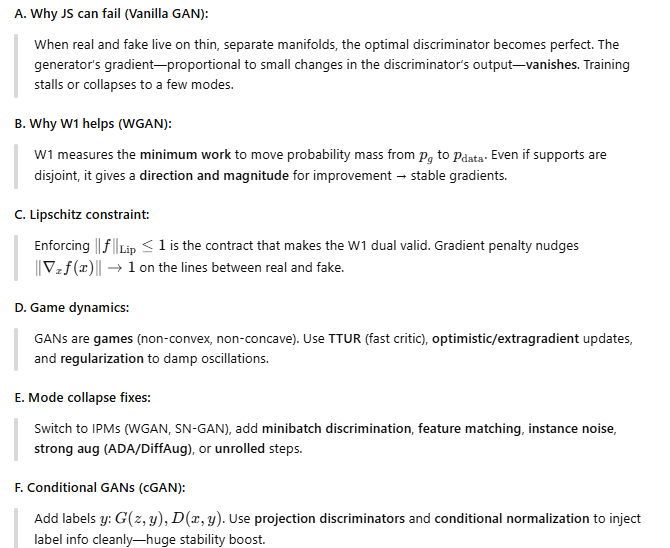

(Notebook created for AI Concepts and Workouts, Last updated on Jan 2026)